In [ ]:
import psi4
import numpy as np
import pandas as pd

# Set Psi4 options

psi4.set_memory('2 GB')
psi4.set_num_threads(4)
print(f"Threads in use: {psi4.get_num_threads()}")

psi4.set_options({
    'print': 0,
#    'scf__print': 0,
#    'optking__print': 1,
    'basis': 'STO-3G',
#    'basis': '6-31G*',
    'scf_type': 'df',
    'optking__frozen_dihedral': '1 2 3 4'
    })



psi4.set_memory('2 GB')
psi4.set_options({
    'basis': '6-31G*',
    'scf_type': 'df'
})

# Define base butane geometry (Z-matrix for easy dihedral manipulation)
butane_template = """
0 1
C
C 1 1.54
C 2 1.54 1 112.0
C 3 1.54 2 112.0 1 {phi}
H 1 1.09 2 109.5 3 180.0
H 1 1.09 2 109.5 3 60.0
H 1 1.09 2 109.5 3 -60.0
H 2 1.09 3 109.5 1 180.0
H 2 1.09 3 109.5 1 60.0
H 3 1.09 4 109.5 2 180.0
H 3 1.09 4 109.5 2 60.0
H 4 1.09 3 109.5 2 -60.0
H 4 1.09 3 109.5 2 60.0
H 4 1.09 3 109.5 2 180.0
"""

# Define scan range (0 to 360 degrees)
angles = np.linspace(0, 360, 37)  # every 10 degrees
energies = []

for phi in angles:
    print(f"Calculating for dihedral = {phi:.1f} deg")

    # Create molecule with current dihedral
    mol = psi4.geometry(butane_template.format(phi=phi))

    # Compute energy (no optimization)
    %time energy = psi4.energy("scf", molecule=mol)

    energies.append(energy)

# Convert to relative energies (kcal/mol)
energies_array = np.array(energies)
energies_array = energies_array - energies_array.min()
energies_array = energies_array * 627.509 * 4.184  # Hartree → kJ/mol

# Print results
print("\nAngle (deg)   Energy (kJ/mol)")
for angle, energy in zip(angles, energies_array):
    print(f"{angle:8.1f}   {energy:12.4f}")

print("\nScan complete.")

# make dataframe from angles and energies
df2 = pd.DataFrame({
    'Dihedral Angle (deg)': angles,
    'Energy (kJ/mol)': energies_array
    })

Threads in use: 1
  Memory set to   1.863 GiB by Python driver.
  Threads set to 1 by Python driver.

Calculating for dihedral = 0.0 deg

  Memory set to   1.863 GiB by Python driver.

Scratch directory: /Users/blink/PSI4_SCRATCH/
   => Libint2 <=

    Primary   basis highest AM E, G, H:  7, 6, 3
    Auxiliary basis highest AM E, G, H:  7, 7, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on MacBook-Air.local
*** at Mon Jun 15 08:26:03 2026

   => Loading Basis Set <=

    Name: 6-31G*
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-4  entry C          line   111 file /Users/blink/miniconda3/envs/ipymol/share/psi4/basis/6-31gs.gbs 
    atoms 5-14 entry H          line    44 file /Users/blink/miniconda3/envs/ipymol/share/psi4/basis/6-31gs.gbs 

   => Loading Basis Set <=

    Name: (6-31G* AUX)
    Role: JKFIT
    Keyword: DF_BASIS_SCF
    atoms 1-4  entry C          line   121 file /Users/blink/miniconda3/envs/

In [9]:
df2.to_csv("butane_scan.csv", index=False)

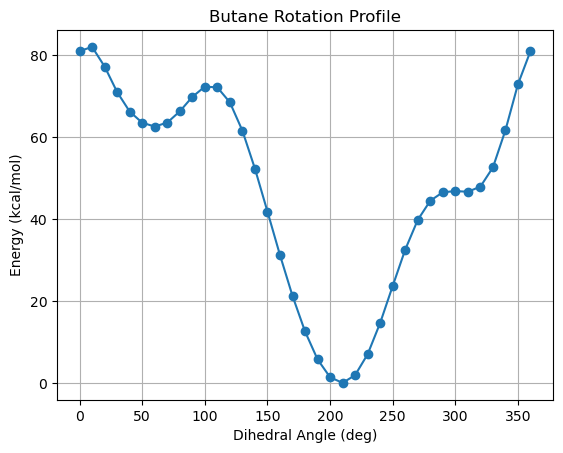

In [11]:
import matplotlib.pyplot as plt

plt.plot(df2["Dihedral Angle (deg)"], df2["Energy (kJ/mol)"], marker='o')
plt.xlabel("Dihedral Angle (deg)")
plt.ylabel("Energy (kcal/mol)")
plt.title("Butane Rotation Profile")
plt.grid()
plt.show()


In [ ]:
import psi4
import numpy as np
import pandas as pd

# Set Psi4 options

psi4.core.set_output_file("butane_scan.log", True)

psi4.set_memory('2 GB')
psi4.set_num_threads(4)
print(f"Threads in use: {psi4.get_num_threads()}")

psi4.set_options({
    'print': 0,
#    'scf__print': 0,
#    'optking__print': 1,
    'basis': 'STO-3G',
#    'basis': '6-31G*',
    'scf_type': 'df',
    'optking__frozen_dihedral': '1 2 3 4'
    })

# Define base butane geometry (Z-matrix for easy dihedral manipulation)
butane_template = """
0 1
C
C 1 1.54
C 2 1.54 1 112.0
C 3 1.54 2 112.0 1 {phi}
H 1 1.09 2 109.5 3 181.0
H 1 1.09 2 109.5 3 61.0
H 1 1.09 2 109.5 3 -61.0
H 2 1.09 3 109.5 1 181.0
H 2 1.09 3 109.5 1 61.0
H 3 1.09 4 109.5 2 181.0
H 3 1.09 4 109.5 2 61.0
H 4 1.09 3 109.5 2 -61.0
H 4 1.09 3 109.5 2 61.0
H 4 1.09 3 109.5 2 181.0
"""

# Define scan range (0 to 360 degrees)
angles = np.linspace(0, 360, 37)  # every 10 degrees
energies = []

for phi in angles:
    print(f"Calculating for dihedral = {phi:.1f} deg")

    # Create molecule with current dihedral
    mol = psi4.geometry(butane_template.format(phi=phi))

    # Compute energy (no optimization)
        
    energy = psi4.optimize("scf", molecule=mol, return_wfn=False)


    energies.append(energy)

# Convert to relative energies (kcal/mol)
energies_array = np.array(energies)
energies_array = energies_array - energies_array.min()
energies_array = energies_array * 627.509 * 4.184  # Hartree → kJ/mol

# Print results
print("\nAngle (deg)   Energy (kJ/mol)")
for angle, energy in zip(angles, energies_array):
    print(f"{angle:8.1f}   {energy:12.4f}")

print("\nScan complete.")

# make dataframe from angles and energies
df = pd.DataFrame({
    'Dihedral Angle (deg)': angles,
    'Energy (kJ/mol)': energies_array
    })

In [7]:
df.to_csv("butane_scan_optimized.csv", index=False)

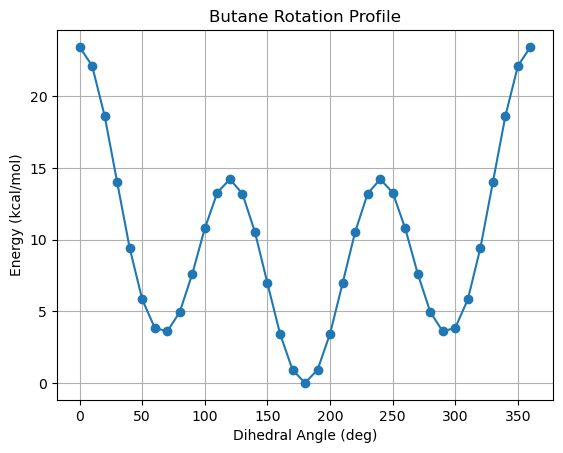

In [6]:
import matplotlib.pyplot as plt

plt.plot(df["Dihedral Angle (deg)"], df["Energy (kJ/mol)"], marker='o')
plt.xlabel("Dihedral Angle (deg)")
plt.ylabel("Energy (kcal/mol)")
plt.title("Butane Rotation Profile")
plt.grid()
plt.show()
